In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from sbi.utils import BoxUniform
from torch.distributions import LogNormal, Independent
from joblib import Parallel, delayed
from sbi.analysis import pairplot
from sbi.inference import NPE
from sbi.analysis import plot_summary

_ = torch.manual_seed(42)

_ = np.random.seed(0)

# Define Lotka Volterra Simulator
def lotka_volterra(y, alpha, beta, delta, gamma):
    prey, predator = y
    dprey_dt = alpha * prey - beta * prey * predator
    dpredator_dt = delta * prey * predator - gamma * predator
    return np.asarray([dprey_dt, dpredator_dt])

def simulate_total(parameters, t_span):
    alpha = parameters[0]
    beta = parameters[1]
    delta = parameters[2]
    gamma = parameters[3]

    y0 = np.asarray([40.0, 9.0])  # Initial populations
    #t_span = 400  # Total simulation time
    dt = 0.1  # Time step

    timesteps = int(2*t_span / dt)
    y = np.zeros((timesteps, 2))
    y[0] = y0

    for i in range(1, timesteps):
        y[i] = y[i-1] + lotka_volterra(y[i-1], alpha, beta, delta, gamma) * dt

    return y

def choose_splitter(nparray, split_method):
    if split_method == 'even_odd':
        return split_by_even_odd(nparray)
    elif split_method == 'first_second':
        return split_in_two(nparray)
    else:
        raise ValueError(f"Unknown split type: {split_method}")
    

# split into two halves
def split_in_two(nparray):
    n = len(nparray)
    mid = n//2
    res1 = nparray[:mid]
    res2 = nparray[mid:]
    return res1, res2

# split by even/odd indices
def split_by_even_odd(nparray):
    even = nparray[::2]
    odd = nparray[1::2]
    m = min(len(even), len(odd))
    even, odd = even[:m], odd[:m]
    return even, odd


# Define how populations evolve
def simulate(parameters, observation, t_span):
    alpha = parameters[0]
    beta = parameters[1]
    delta = parameters[2]
    gamma = parameters[3]


    y0 = np.asarray([observation[0, 0], observation[0, 1]])  # Initial populations
    #t_span = 200  # Total simulation time
    dt = 0.1  # Time step

    timesteps = int(t_span / dt)
    y = np.zeros((timesteps, 2))
    y[0] = y0

    for i in range(1, timesteps):
        y[i] = y[i-1] + lotka_volterra(y[i-1], alpha, beta, delta, gamma) * dt

    return y

# Extract observed data
def extract_data(url):
    df = pd.read_csv(url, delim_whitespace=True, header=None, index_col=0)
    df.index.name = 'Year'
    df.columns = ['Hare', 'Lynx']
    time_vec = df.index.values
    observation = df[['Hare', 'Lynx']].values
    print(observation.shape)
    n_obs = observation.shape[0]
    sigma_hare = 0.2 * np.std(observation[:, 0])   # 20% of hare std
    sigma_lynx = 0.2 * np.std(observation[:, 1])   # 20% of lynx std
    return time_vec, observation, n_obs, sigma_hare, sigma_lynx

# Plot figures for observed lynx hare populations
def plot_observed_data(time_vec, observation):
    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    _ = ax.plot(time_vec, observation)
    _ = ax.legend(["Prey", "Predator"])
    _ = ax.set_xlabel("Time")
    _ = ax.set_ylabel("Population")

# Use mean and max as summary statistics but add noise: intended for our actual observation
def add_noise_and_plot(simulation_result, distn, sigma_hare, sigma_lynx, time):

    if distn == 'none':
        pass
    elif distn == 'gaussian':
        noise = np.random.normal(
        loc=0.0,
        scale=np.array([sigma_hare, sigma_lynx]),  # one sigma per column
        size=simulation_result.shape)
        simulation_result = simulation_result + noise
    elif distn == 'poisson':
        lam = np.clip(simulation_result, 1e-6, None)
        simulation_result = np.random.poisson(lam)
    else:
        raise ValueError(f"Unknown distribution type: {distn}")

    plot_observed_data(time,simulation_result)

    
    return simulation_result

# Use mean and max as summary statistics
def summarize_simulation(simulation_result):

    prey_population = simulation_result[:, 0]
    predator_population = simulation_result[:, 1]
    
    summary = [
        np.max(prey_population).item(),
        np.max(predator_population).item(),
        np.mean(prey_population).item(),
        np.mean(predator_population).item()
    ]
    return np.asarray(summary)

# pick out n_obs points to ensure arrays are same size
def downsample_to_n_obs(sim_result, n_obs):
    # pick out n_obs points to ensure arrays are same size
    T = sim_result.shape[0]
    idx = np.linspace(0, T - 1, n_obs).astype(int)
    return sim_result[idx]

# returns data that is same size as observed, adding no noise
def simulate_match_data(parameters, n_obs,observation, t_span):
    # returns data that is same size as observed, adding no noise
    full_traj = simulate(parameters,observation,t_span)            # (2000, 2)
    return downsample_to_n_obs(full_traj, n_obs)  # (n_obs, 2)

# Returns simulations with gaussian noise added
def simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx, observation, t_span):
    latent = simulate_match_data(parameters, n_obs,observation, t_span)
    noise = np.random.normal(
        loc=0.0,
        scale=np.array([sigma_hare, sigma_lynx]),  # one sigma per column
        size=latent.shape
    )
    # Column 0 ~ N(0, sigma_hare^2), column 1 ~ N(0, sigma_lynx^2)
    noisy = latent + noise
    return noisy

# Return simulations with poissoin noise added
def simulate_poisson(parameters, n_obs, observation, t_span):
    latent = simulate_match_data(parameters, n_obs, observation, t_span)
    lam = np.clip(latent, 1e-6, None)
    noisy_counts = np.random.poisson(lam)
    return noisy_counts

# Wrapper function to choose noise
def simulator_distribution(distn, parameters, n_obs, sigma_hare, sigma_lynx, observation, t_span):
    if distn == 'none':
        result = simulate_match_data(parameters, n_obs, observation,t_span)
    elif distn == 'gaussian':
        result = simulate_gaussian(parameters, n_obs, sigma_hare, sigma_lynx, observation, t_span)
    elif distn == 'poisson':
        result = simulate_poisson(parameters, n_obs, observation, t_span)
    else:
        raise ValueError(f"Unknown distribution type: {distn}")
    return result

# Define a uniform prior
def define_uniform_prior():
    lower_bound = torch.as_tensor([0.05, 0.01, 0.005, 0.005])
    upper_bound = torch.as_tensor([0.15, 0.03, 0.03, 0.15])
    prior = BoxUniform(low=lower_bound, high=upper_bound)
    return prior

# Define a log-normal prior
def define_logn_prior():
    log_means = torch.log(torch.tensor([
        0.13,   # alpha - 1.6   old: 0.1
        0.015,   # beta - 3.2   old: 0.02
        0.008,  # delta - 0.6    old: 0.015
        0.12    # gamma - 0.56     old: 0.08
    ]))

    log_stds = torch.tensor([0.3, 0.3, 0.3, 0.3]) # old was just 0.3

    # Build prior
    base_dist = LogNormal(loc=log_means, scale=log_stds)
    prior_lognormal = Independent(base_dist, 1)
    return prior_lognormal


# Wrapper Function to choose prior distn
def choose_prior_and_generate_theta(distn):
    if distn == 'uniform':
        prior = define_uniform_prior()
    elif distn == 'logn':
        prior = define_logn_prior()
    else:
        raise ValueError(f"Unknown distribution type: {distn}")
    
    theta = prior.sample((10_000,))
    return prior, theta

# simulator function
def parallel_simulate(theta,distn, n_obs, sigma_hare, sigma_lynx, observation, t_span):
    # Our simulator uses numpy, but prior samples are in PyTorch.
    theta_np = theta.numpy()

    num_workers = 8
    simulation_outputs = Parallel(n_jobs=num_workers)(
        delayed(simulator_distribution)(distn,batch,n_obs, sigma_hare, sigma_lynx, observation, t_span)
        for batch in theta_np
    )
    return np.asarray(simulation_outputs)

# generate simulations
def generate_x(theta,distn, n_obs,sigma_hare,sigma_lynx, observation, t_span):
    simulation_outputs = parallel_simulate(theta,distn, n_obs,sigma_hare, sigma_lynx, observation, t_span)
    x = torch.as_tensor(np.asarray([summarize_simulation(sim) for sim in simulation_outputs]), dtype=torch.float32)
    return x

# plot to check simulated data covers observed data
def plot_checker(x, x_obs):
        _ = pairplot(
        samples=x,
        points=x_obs[None, :],  # `points` needs a batch dimension.
        limits=[[0, 200], [0, 150], [0, 25], [0, 50]],
        figsize=(4, 4),
    )


WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [2]:

# Generate net, stopping after max epochs, choosing or not choosing to 
def train_net_generate_samples(x,theta,x_obs, prior, verbose, max_epoch,true_val):
    
    inference = NPE(prior= prior, density_estimator="nsf")
    posterior_net = inference.append_simulations(theta, x).train(max_num_epochs=max_epoch, stop_after_epochs=30)
    posterior_direct = inference.build_posterior(density_estimator=posterior_net,sample_with="direct")
    posterior_mcmc = inference.build_posterior(density_estimator=posterior_net,sample_with="mcmc")
    samples = posterior_mcmc.sample((1_000,), x=x_obs)

    if verbose == True:
        _ = plot_summary(
        inference,
        tags=["training_loss", "validation_loss"],
        figsize=(10, 2),
        )

        print(posterior_mcmc)
        print("Observation: ", x_obs)

        _ = pairplot(
            samples,
            points = true_val[None,:],
            limits=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
            ticks=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
            figsize=(5, 5),
            labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
            )
        
    return samples, posterior_mcmc, posterior_direct, inference

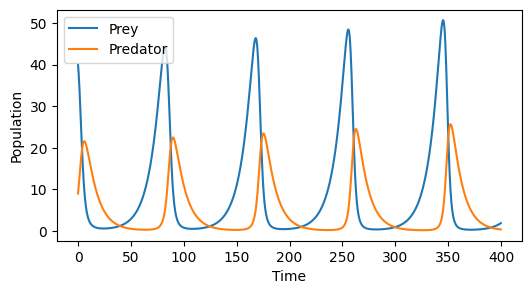

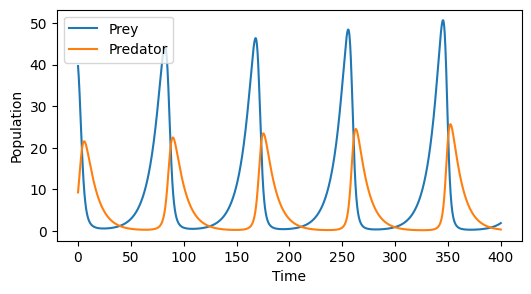

In [3]:
t_span = 200
time_vec = np.arange(0, 2*t_span, 0.1)
true_parameters = np.asarray([0.1, 0.02, 0.01, 0.1])
split_type =  "even_odd"#"first_second"

observation = simulate_total(true_parameters,t_span)

time1, time2 = choose_splitter(time_vec,split_type)
obs1, obs2 = choose_splitter(observation,split_type)

plot_observed_data(time1, obs1)
plot_observed_data(time2, obs2) # THIS IS OBSERVATIOSN WITHOUT NOISE ADDED





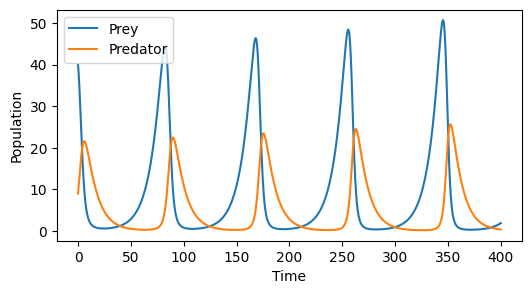

In [5]:
plot_observed_data(time_vec, observation)

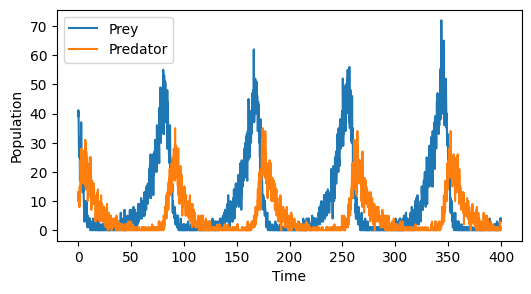

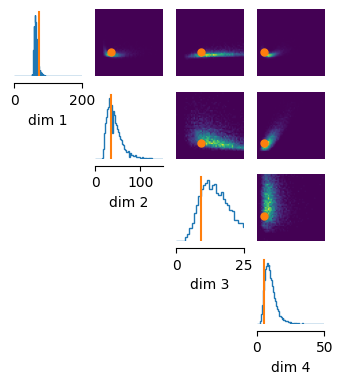

In [4]:
sigma_hare1 = 0.2 * np.std(obs1[:, 0])   # 20% of hare std
sigma_lynx1 = 0.2 * np.std(obs1[:, 1])   # 20% of lynx std
sigma_hare2 = 0.2 * np.std(obs2[:, 0])   # 20% of hare std
sigma_lynx2 = 0.2 * np.std(obs2[:, 1])   # 20% of lynx std
n_obs1 = len(obs1)
n_obs2 = len(obs2)

prior_name = 'logn' #prior =  'uniform' 
noise1 =   'poisson' #'gaussian' 'none'
noise2 = 'gaussian'
max_epoch = 1000

prior1,theta1 = choose_prior_and_generate_theta(prior_name)

x1 = generate_x(theta1,noise1, n_obs1, sigma_hare1, sigma_lynx1, obs1, t_span)

noisy_obs1= add_noise_and_plot(obs1,noise1,sigma_hare1,sigma_lynx1,time1)
x_obs1 = summarize_simulation(noisy_obs1)
plot_checker(x1,x_obs1)



In [32]:
log_theta = torch.log(theta1)
corr = np.corrcoef(log_theta.numpy().T, x1.numpy().T)[:4, 4:]  # 4x4

print("rows = [alpha,beta,delta,gamma], cols = [dim1..dim4]")
print(np.round(corr, 3))

rows = [alpha,beta,delta,gamma], cols = [dim1..dim4]
[[ 0.299  0.428  0.035  0.652]
 [ 0.017 -0.594 -0.026 -0.684]
 [-0.244  0.478 -0.67   0.05 ]
 [ 0.295 -0.211  0.671 -0.057]]


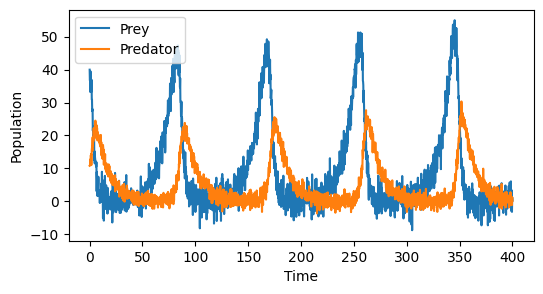

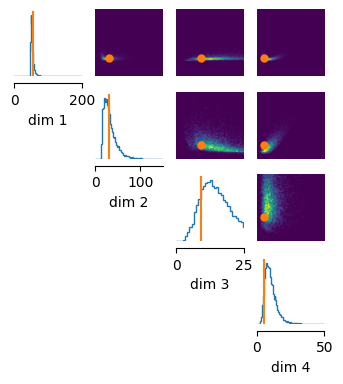

In [5]:
prior2,theta2 = choose_prior_and_generate_theta(prior_name)
x2 = generate_x(theta2,noise2, n_obs2, sigma_hare2, sigma_lynx2, obs2, t_span)

noisy_obs2= add_noise_and_plot(obs2,noise2,sigma_hare2,sigma_lynx2,time2)
x_obs2 = summarize_simulation(noisy_obs2)
plot_checker(x2,x_obs2)

 Neural network successfully converged after 288 epochs.

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\vasir\Documents\0 Research Project\Lotka-Volterra\sbi-logs\NPE_C\2026-02-05T16_26_48.909651' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


Posterior p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
Observation:  [63.     33.      9.5115  5.9895]


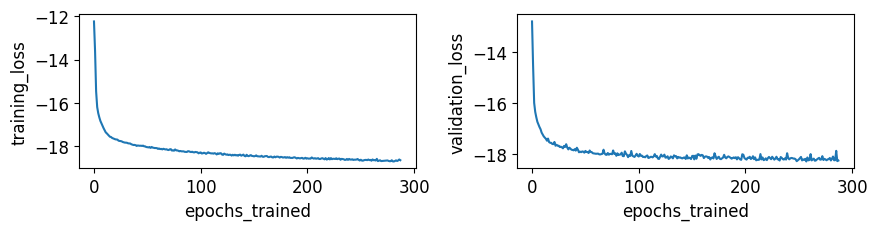

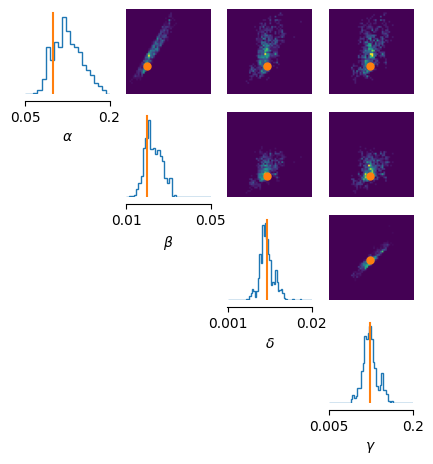

In [34]:
samples1, posterior1_mcmc, posterior1_direct, inference1 = train_net_generate_samples(x1,theta1,x_obs1, prior1, verbose = True, max_epoch=1000, true_val=true_parameters)

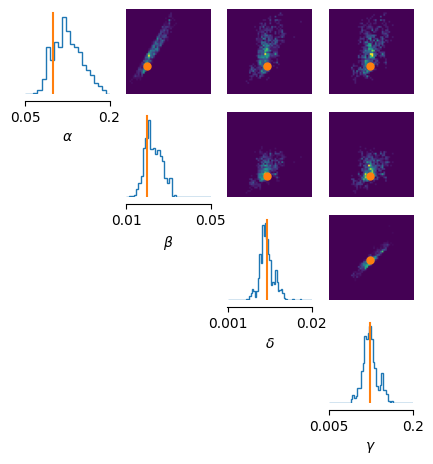

In [35]:
_ = pairplot(
            samples1,
            points = true_parameters[None,:],
            limits=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
            ticks=[[0.05, 0.2], [0.01, 0.05], [0.001, 0.02], [0.005, 0.2]],
            figsize=(5, 5),
            labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
            )

 Neural network successfully converged after 350 epochs.

c:\Users\vasir\Documents\0 Research Project\.venv\Lib\site-packages\sbi\inference\posteriors\mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

For an interactive, detailed view of the summary, launch tensorboard  with 'tensorboard --logdir=c:\Users\vasir\Documents\0 Research Project\Lotka-Volterra\sbi-logs\NPE_C\2026-02-05T16_43_52.781166' from a terminal on your machine, visit http://127.0.0.1:6006 afterwards. Requires port forwarding if tensorboard runs on a remote machine, as e.g. https://stackoverflow.com/a/42445070/7770835 explains.

Valid tags are: ['best_validation_loss', 'epoch_durations_sec', 'epochs_trained', 'training_loss', 'validation_loss'].


Posterior p(θ|x) of type MCMCPosterior. It provides MCMC to .sample() from the posterior and can evaluate the _unnormalized_ posterior density with .log_prob().
Observation:  [54.59748215 28.06655173  9.05481601  4.5881855 ]


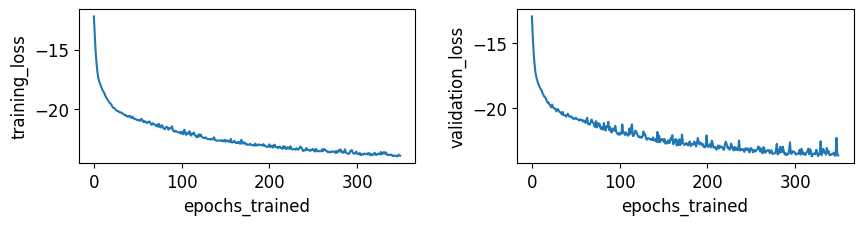

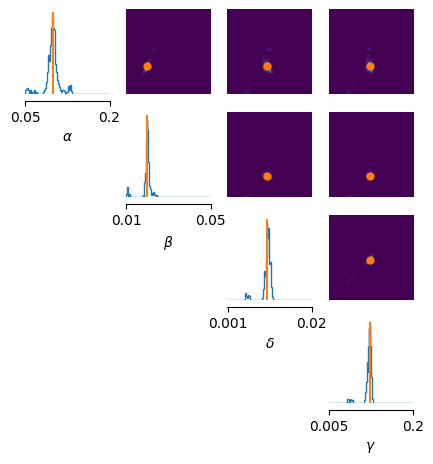

In [36]:
samples2, posterior2_mcmc, posterior2_direct, inference2 = train_net_generate_samples(x2,theta2,x_obs2, prior2, verbose = True, max_epoch=1000, true_val=true_parameters)

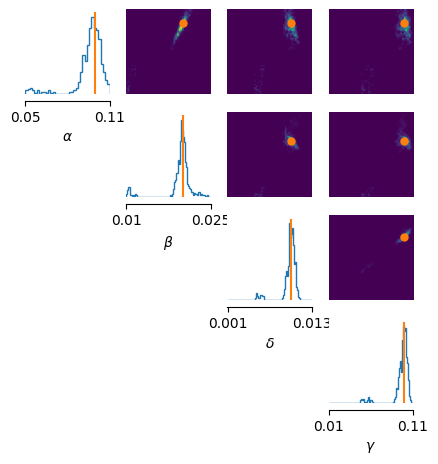

In [39]:
_ = pairplot(
            samples2,
            points = true_parameters[None,:],
            limits=[[0.05, 0.11], [0.01, 0.025], [0.001, 0.013], [0.01, 0.11]],
            ticks=[[0.05, 0.11], [0.01, 0.025], [0.001, 0.013], [0.01, 0.11]],
            figsize=(5, 5),
            labels=[r"$\alpha$", r"$\beta$", r"$\delta$", r"$\gamma$"]
            )

In [40]:
results = {
        "samples1": samples1,          # posterior samples (1000, 4)
        "samples2": samples2,          # posterior samples (1000, 4)
        "posterior1_mcmc": posterior1_mcmc,   # sbi posterior object (if you want to reuse it)
        "posterior1_direct": posterior1_direct,   # sbi posterior object (if you want to reuse it)
        "posterior2_mcmc": posterior2_mcmc,   # sbi posterior object (if you want to reuse it)
        "posterior2_direct": posterior2_direct,   # sbi posterior object (if you want to reuse it)
        "inference1": inference1,      # NPE object
        "inference2": inference2,      # NPE object
        "prior1": prior1,
        "prior2": prior2,
        "theta1": theta1,              # simulated θ used for training (10000, 4)
        "theta2": theta2,              # simulated θ used for training (10000, 4)
        "x1": x1,                      # simulated summaries (10000, 4)
        "x2": x2,                      # simulated summaries (10000, 4)
        "x_obs1": x_obs1,              # observed summary (4,)
        "x_obs2": x_obs2,              # observed summary (4,)
        "time_vec1": time1,        # years
        "time_vec2": time2,        # years
        "obs1": obs1,               # raw data (n_obs, 2)
        "obs2": obs2,               # raw data (n_obs, 2)
        "prior_name": prior_name,    # 'uniform' or 'logn'
        "noise1": noise1,        # 'none' / 'gaussian' / 'poisson'
        "noise2": noise2,        # 'none' / 'gaussian' / 'poisson'
        "n_obs1": n_obs1,
        "n_obs2": n_obs2,
        "sigma_hare1": sigma_hare1,
        "sigma_lynx1": sigma_lynx1,
        "sigma_hare2": sigma_hare2,
        "sigma_lynx2": sigma_lynx2,
        "split_type": split_type,
        "t_span": t_span,
        "true_parameters": true_parameters
    }


fname = f"CALIBRATION TESTER_split_{split_type}_results_{prior_name}_{noise1}_1000EPOCH.pt"
torch.save(results, fname)

c:\Users\vasir\Documents\0 Research Project\.venv\Lib\site-packages\torch\serialization.py:1088: UserWarning: When the inference object is pickled, the behaviour of the loaded object changes in the following two ways: 1) `.train(..., retrain_from_scratch=True)` is not supported. 2) When the loaded object calls the `.train()` method, it generates a new tensorboard summary writer (instead of appending to the current one).
  pickler.dump(obj)


In [ ]:
def calc_dkl(posterior1, posterior2, x1, x2, n_theta):
    
    # Setting data as tensors to use with sbi lib
    x1 = torch.as_tensor(x1, dtype=torch.float32).reshape(1,-1)
    x2 = torch.as_tensor(x2, dtype=torch.float32).reshape(1,-1)

    with torch.no_grad(): # included this line to help with speed
        #take n_theta samples of data 
        theta_samples = posterior1.sample((n_theta,),x=x1, show_progress_bars = False)

        # access log probabilities
        log_post1 = posterior1.log_prob(theta_samples, x=x1, norm_posterior=True) # Changed back to true
        log_post2 = posterior2.log_prob(theta_samples, x=x2, norm_posterior=True) 

        #Compute and return test statistic
        return (log_post1 - log_post2).mean().item()

def calibrate_null_dkl(null_posterior, prior, N, n_theta, distn, n_obs, sigma_hare, sigma_lynx, observation, split_type, t_span):

    dkls = np.zeros(N) # to store dkls
    for i in range(N):
        if i % 20 == 0:
            print(f"{i}/{N}")

        #obtain data splits generated by same simulation process
        theta_i = prior.sample((1,)).squeeze(0).detach().numpy()
        #traj_i = simulate_total(theta_i)
        traj_i = simulator_distribution(distn, theta_i, n_obs, sigma_hare, sigma_lynx, observation, t_span)
        obs1_i, obs2_i = choose_splitter(traj_i,split_type)
        #

        # Q: if we are using posterior 1 as a null, should we add whatever noise was added to train posterior 1 training data here?

        x1_i = summarize_simulation(obs1_i) 
        x2_i = summarize_simulation(obs2_i) #obtaining summary statistics of data

        dkls[i] = calc_dkl(null_posterior, null_posterior, x1_i, x2_i, n_theta=n_theta) # update dkl

    # 95 percent critical value
    crit_val_95 = float(np.quantile(dkls, 0.95))
    
    #plot histogram
    plt.figure(figsize=(6, 3))
    plt.hist(dkls, bins=30, density=True)
    plt.xlabel("D_KL")
    plt.ylabel("density")
    plt.title("Null calibration of D_KL (data realisations under null)")
    plt.show()

    print("Null 95 percent critical value:", crit_val_95)

    return dkls, crit_val_95


In [ ]:

dkl_obs = calc_dkl(posterior1_direct, posterior2_direct, x_obs1, x_obs2, n_theta = 500)


dkls, crit_val_95 = calibrate_null_dkl(posterior1_direct, prior1,100,500, noise1, n_obs1, sigma_hare1, sigma_lynx1, obs1, split_type, t_span)
print("DKL observed:", dkl_obs)        



0/100


                        constant for `log_prob()`. However, only
                        0.000% posterior samples are within the
                        prior support (for condition 0). It may take a long time
                        to collect the remaining 10000 samples.
                        Consider interrupting (Ctrl-C) and either basing the
                        estimate of the normalizing constant on fewer samples (by
                        calling `posterior.leakage_correction(x_o,
                        num_rejection_samples=N)`, where `N` is the number of
                        samples you want to base the
                        estimate on (default N=10000), or not estimating the
                        normalizing constant at all
                        (`log_prob(..., norm_posterior=False)`. The latter will
                        result in an unnormalized `log_prob()`.


KeyboardInterrupt: 

0/200
20/200
40/200
60/200
80/200
100/200
120/200
140/200
160/200
180/200


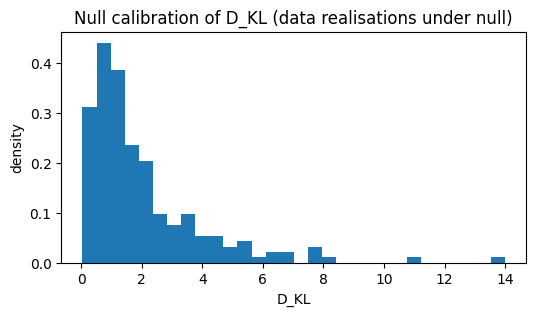

Null 95 percent critical value: 5.735693049430836
DKL observed: 14.70590591430664


In [ ]:

dkl_obs = calc_dkl(posterior1_direct, posterior2_direct, x_obs1, x_obs2, n_theta = 2500)


dkls, crit_val_95 = calibrate_null_dkl(posterior1_direct, prior1,200,2500, noise1, n_obs1, sigma_hare1, sigma_lynx1, obs1, split_type, t_span)
print("DKL observed:", dkl_obs)    

In [ ]:
#loop through N vals to see error as fn of n
N_theta_vals = [100,500,1000,5000,10000]


